# Level shift - analisi di sensibilità del detector

Questo notebook valuta la robustezza del detector LSTM per anomalie di tipo `level_shift`.

L'obiettivo non è scegliere i parametri ottimizzando sulla ground truth, ma studiare come cambiano le metriche quando, a partire da una configurazione base ragionevole, si varia **un solo parametro alla volta**.

La ground truth viene usata solo nella fase finale di valutazione event-level.

## Setup

Il notebook assume che:

- il modello LSTM sales sia già stato addestrato e salvato in `artifacts/models/sales`;
- i dataset di sensitivity siano nella cartella `artifacts/data/datasets/level_shift/sensitivity`;
- le utility `lstm_utils.py` e `sales_level_shift_utils.py` siano nella root del progetto.

La finestra temporale corrisponde al modello sales selezionato.

In [1]:
# =========================================================
# PATH
# =========================================================

import sys
from pathlib import Path

start_dir = Path.cwd().resolve()

for candidate in [start_dir, *start_dir.parents]:
    if (candidate / "project_paths.py").is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Root del progetto non trovata. "
        "Avvia Jupyter da una cartella interna alla repository."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from project_paths import (
    CLEAN_DATA_PATH,
    LEVEL_SHIFT_RESULTS_DIR,
    LEVEL_SHIFT_SENSITIVITY_DIR,
    SALES_MODEL_DIR,
    ensure_artifact_directories
)


import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tqdm.auto import tqdm
from IPython.display import display

from lstm_utils import (
    build_dataset_inference,
    build_model_inputs,
    make_results_df,
)

from sales_level_shift_utils import (
    list_sensitivity_datasets,
    add_level_shift_score,
    compute_level_shift_std_thresholds_by_store,
    detect_level_shift_from_score_by_store,
    build_detected_windows_from_center_points,
    build_gt_level_shift_windows,
    evaluate_detected_windows_event_level,
    run_sales_lstm_inference_for_dataset,
    run_level_shift_std_detector_details,
    infer_model_window_size,
    normalize_sales_feature_schema,
)

pd.set_option("display.max_columns", None)

## Configurazione

I parametri inclusi nell'analisi sono:

- `score_window`: finestra usata per aggregare i residui nello score;
- `n_std`: soglia in deviazioni standard stimata su validation;
- `min_consecutive`: numero minimo di rilevazioni vicine richieste per formare un evento;
- `gap_tolerance`: numero di giorni non rilevati tollerati tra rilevazioni della stessa finestra.

`iou_threshold` resta fisso, perché è un parametro della valutazione e non del detector.

In [3]:
ensure_artifact_directories()

BASE_SENSITIVITY_PATH = LEVEL_SHIFT_SENSITIVITY_DIR
MODEL_DIR = SALES_MODEL_DIR

OUTPUT_DIR = LEVEL_SHIFT_RESULTS_DIR / "detector_sensitivity_one_at_a_time"
CACHE_DIR = OUTPUT_DIR / "_cache_lstm_results"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

# Artifact separati per il confronto STD/MAD/Double MAD.
THRESHOLD_OUTPUT_DIR = OUTPUT_DIR / "threshold_method_comparison"
THRESHOLD_CACHE_DIR = THRESHOLD_OUTPUT_DIR / "_cache"
THRESHOLD_FIGURES_DIR = THRESHOLD_OUTPUT_DIR / "figures"
THRESHOLD_TABLES_DIR = THRESHOLD_OUTPUT_DIR / "tables"

for path in [
    OUTPUT_DIR,
    CACHE_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    THRESHOLD_OUTPUT_DIR,
    THRESHOLD_CACHE_DIR,
    THRESHOLD_FIGURES_DIR,
    THRESHOLD_TABLES_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)


# Configurazione base del detector.
BASE_CONFIG = {
    "score_window": 7,
    "n_std": 3.5,
    "min_consecutive": 3,
    "gap_tolerance": 1,
    "iou_threshold": 0.20,
}

PARAMETER_VALUES = {
    "score_window": [3, 5, 7, 10, 14],
    "n_std": [2.5, 3.0, 3.5, 4.0, 4.5],
    "min_consecutive": [1, 2, 3, 4, 5],
    "gap_tolerance": [0, 1, 2, 3, 4],
}

# Soglie operative usate solo per sintetizzare i risultati per severità.
SOFT_SEVERITY_THRESHOLD = 0.05
MEDIUM_SEVERITY_THRESHOLD = 0.15
# Cache/recompute.
# L'inference e la griglia del detector possono essere ricalcolate separatamente.
FORCE_RECOMPUTE_INFERENCE = False
FORCE_RECOMPUTE_DETECTOR = False
FORCE_RECOMPUTE_THRESHOLD_COMPARISON = False

# Utile per test veloci. Lasciare None per l'esperimento completo.
DEBUG_MAX_DATASETS = None

RAW_RESULTS_PATH = OUTPUT_DIR / "level_shift_detector_sensitivity_raw_results.csv"
EVENT_RESULTS_PATH = OUTPUT_DIR / "level_shift_detector_sensitivity_event_level.csv"
AGG_RESULTS_PATH = OUTPUT_DIR / "level_shift_detector_sensitivity_aggregated.csv"

THRESHOLD_VAL_RESULTS_CACHE_PATH = (
    THRESHOLD_CACHE_DIR / "clean_val_results.pkl"
)
THRESHOLD_RAW_METRICS_PATH = (
    THRESHOLD_TABLES_DIR / "threshold_method_event_metrics_raw_by_store.csv"
)
THRESHOLD_FINAL_METRICS_PATH = (
    THRESHOLD_TABLES_DIR / "threshold_method_metrics_summary.csv"
)

print("BASE_SENSITIVITY_PATH:", BASE_SENSITIVITY_PATH)
print("MODEL_DIR:", MODEL_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("THRESHOLD_OUTPUT_DIR:", THRESHOLD_OUTPUT_DIR)
BASE_CONFIG

BASE_SENSITIVITY_PATH: C:\Users\ciok4\jupyter file\tesi\artifacts\data\datasets\level_shift\sensitivity
MODEL_DIR: C:\Users\ciok4\jupyter file\tesi\artifacts\models\sales
OUTPUT_DIR: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\detector_sensitivity_one_at_a_time
THRESHOLD_OUTPUT_DIR: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\detector_sensitivity_one_at_a_time\threshold_method_comparison


{'score_window': 7,
 'n_std': 3.5,
 'min_consecutive': 3,
 'gap_tolerance': 1,
 'iou_threshold': 0.2}

In [4]:
model = tf.keras.models.load_model(
    MODEL_DIR / "lstm_sales.keras"
)

MODEL_WINDOW_SIZE = infer_model_window_size(model)
print("Window size del modello caricato:", MODEL_WINDOW_SIZE)

with open(MODEL_DIR / "feature_scalers.pkl", "rb") as f:
    feature_scalers = pickle.load(f)

with open(MODEL_DIR / "mappings.pkl", "rb") as f:
    mappings = pickle.load(f)

with open(MODEL_DIR / "features.pkl", "rb") as f:
    features = pickle.load(f)

features = normalize_sales_feature_schema(features)

Window size del modello caricato: 28


## Dataset sensitivity

Ogni dataset corrisponde a una combinazione di direzione, durata, moltiplicatore e seed.  
Il modello e il detector vengono valutati su tutti i dataset disponibili.

In [5]:
if not BASE_SENSITIVITY_PATH.exists():
    raise FileNotFoundError(
        f"Cartella sensitivity non trovata: {BASE_SENSITIVITY_PATH}"
    )


def classify_level_shift_severity(multiplier):
    """Classifica la severità usando la distanza del moltiplicatore da 1."""
    delta = abs(float(multiplier) - 1.0)

    if delta <= SOFT_SEVERITY_THRESHOLD:
        return "soft"

    if delta <= MEDIUM_SEVERITY_THRESHOLD:
        return "medium"

    return "hard"


datasets_df = list_sensitivity_datasets(BASE_SENSITIVITY_PATH)

# Ordine stabile per cache, tabelle e progress bar.
datasets_df = datasets_df.sort_values(
    ["direction", "duration", "multiplier", "seed"]
).reset_index(drop=True)

datasets_df["severity_class"] = datasets_df["multiplier"].apply(
    classify_level_shift_severity
)

if DEBUG_MAX_DATASETS is not None:
    datasets_df = datasets_df.head(DEBUG_MAX_DATASETS).copy()

print("Numero dataset:", len(datasets_df))
display(datasets_df.head())

coverage_table = (
    datasets_df
    .groupby(["direction", "severity_class", "duration", "multiplier"], as_index=False)
    .agg(n_datasets=("seed", "count"))
    .sort_values(["direction", "severity_class", "duration", "multiplier"])
)

coverage_table.to_csv(TABLES_DIR / "level_shift_sensitivity_dataset_coverage.csv", index=False)
display(coverage_table.head(20))

Numero dataset: 280


,path,direction,duration,multiplier,seed,severity_class
0,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,42,hard
1,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,43,hard
2,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,44,hard
3,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,45,hard
4,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,46,hard


,direction,severity_class,duration,multiplier,n_datasets
0,decrease,hard,7,0.700,5
1,decrease,hard,7,0.800,5
2,decrease,hard,7,0.850,5
3,decrease,hard,10,0.700,5
4,decrease,hard,10,0.800,5
5,decrease,hard,10,0.850,5
6,decrease,hard,14,0.700,5
7,decrease,hard,14,0.800,5
8,decrease,hard,14,0.850,5
9,decrease,hard,21,0.700,5


## Configurazioni one-at-a-time

Ogni gruppo varia un solo parametro rispetto alla configurazione base.  
La configurazione base è inclusa anche come riferimento separato.

In [6]:
def build_one_at_a_time_config_df(base_config, parameter_values):
    rows = []

    # Riga di riferimento della configurazione base.
    rows.append({
        "config_id": 0,
        "variation_group": "base_config",
        "varied_parameter": "base_config",
        "varied_value": "reference",
        **base_config,
    })

    config_id = 1

    for parameter, values in parameter_values.items():
        for value in values:
            # Varia un solo parametro rispetto alla configurazione base.
            cfg = base_config.copy()
            cfg[parameter] = value

            rows.append({
                "config_id": config_id,
                "variation_group": parameter,
                "varied_parameter": parameter,
                "varied_value": value,
                **cfg,
            })

            config_id += 1

    return pd.DataFrame(rows)


detector_configs = build_one_at_a_time_config_df(
    BASE_CONFIG,
    PARAMETER_VALUES,
)

print("Numero configurazioni detector:", len(detector_configs))
display(detector_configs)

Numero configurazioni detector: 21


,config_id,variation_group,varied_parameter,varied_value,score_window,n_std,min_consecutive,gap_tolerance,iou_threshold
0,0,base_config,base_config,reference,7,3.5,3,1,0.2
1,1,score_window,score_window,3,3,3.5,3,1,0.2
2,2,score_window,score_window,5,5,3.5,3,1,0.2
3,3,score_window,score_window,7,7,3.5,3,1,0.2
4,4,score_window,score_window,10,10,3.5,3,1,0.2
5,5,score_window,score_window,14,14,3.5,3,1,0.2
6,6,n_std,n_std,2.5,7,2.5,3,1,0.2
7,7,n_std,n_std,3.0,7,3.0,3,1,0.2
8,8,n_std,n_std,3.5,7,3.5,3,1,0.2
9,9,n_std,n_std,4.0,7,4.0,3,1,0.2


## Utility di valutazione e aggregazione

Le metriche principali sono calcolate a livello evento:

- `precision`: quota di finestre rilevate che corrispondono a eventi reali;
- `recall`: quota di eventi reali rilevati;
- `f1`: media armonica tra precision e recall;
- `mean_iou`: sovrapposizione media tra finestre rilevate e ground truth abbinate.

Le metriche pooled sommano TP, FP e FN su tutti i dataset prima di calcolare precision, recall e F1.

In [7]:
def add_detection_offsets(gt_eval, det_eval):
    """Aggiunge offset start/end tra finestra rilevata e finestra ground truth."""
    gt = gt_eval.copy()

    if gt.empty:
        return gt

    gt["gt_start"] = pd.to_datetime(gt["gt_start"])
    gt["gt_end"] = pd.to_datetime(gt["gt_end"])

    gt["det_offset_start"] = np.nan
    gt["det_offset_end"] = np.nan

    if det_eval is None or det_eval.empty:
        return gt

    det = det_eval.copy()

    det["detected_start"] = pd.to_datetime(det["detected_start"])
    det["detected_end"] = pd.to_datetime(det["detected_end"])

    det_small = det[[
        "detected_id",
        "detected_start",
        "detected_end",
    ]].copy()

    gt = gt.merge(
        det_small,
        left_on="matched_detected_id",
        right_on="detected_id",
        how="left",
    )

    # Gli offset sono definiti solo per gli eventi abbinati.
    matched_mask = gt["matched"].astype(int) == 1

    gt.loc[matched_mask, "det_offset_start"] = (
        gt.loc[matched_mask, "detected_start"]
        - gt.loc[matched_mask, "gt_start"]
    ).dt.days

    gt.loc[matched_mask, "det_offset_end"] = (
        gt.loc[matched_mask, "detected_end"]
        - gt.loc[matched_mask, "gt_end"]
    ).dt.days

    return gt


def pooled_precision(tp, fp):
    return tp / (tp + fp) if (tp + fp) > 0 else np.nan


def pooled_recall(tp, fn):
    return tp / (tp + fn) if (tp + fn) > 0 else np.nan


def pooled_f1(precision, recall):
    if pd.isna(precision) or pd.isna(recall):
        return np.nan
    if precision + recall == 0:
        return np.nan
    return 2 * precision * recall / (precision + recall)


def aggregate_results(df, group_cols):
    """Aggrega metriche event-level con conteggi pooled e medie tra run."""
    if df.empty:
        return pd.DataFrame()

    agg = (
        df
        .groupby(group_cols, as_index=False)
        .agg(
            n_runs=("run_id", "count"),
            n_gt_events=("n_gt_events", "sum"),
            n_detected_events=("n_detected_events", "sum"),
            tp=("tp", "sum"),
            fp=("fp", "sum"),
            fn=("fn", "sum"),
            precision_mean=("precision", "mean"),
            precision_std=("precision", "std"),
            recall_mean=("recall", "mean"),
            recall_std=("recall", "std"),
            f1_mean=("f1", "mean"),
            f1_std=("f1", "std"),
            mean_iou_mean=("mean_iou", "mean"),
            mean_iou_std=("mean_iou", "std"),
            mean_det_offset_start=("mean_det_offset_start", "mean"),
            mean_det_offset_end=("mean_det_offset_end", "mean"),
        )
    )

    # Le metriche pooled sono ricalcolate dopo la somma di TP, FP e FN.
    agg["precision_pooled"] = [
        pooled_precision(tp, fp)
        for tp, fp in zip(agg["tp"], agg["fp"])
    ]

    agg["recall_pooled"] = [
        pooled_recall(tp, fn)
        for tp, fn in zip(agg["tp"], agg["fn"])
    ]

    agg["f1_pooled"] = [
        pooled_f1(p, r)
        for p, r in zip(agg["precision_pooled"], agg["recall_pooled"])
    ]

    return agg


def add_numeric_sort_key(df, value_col="varied_value"):
    out = df.copy()
    out["varied_value_num"] = pd.to_numeric(out[value_col], errors="coerce")
    out = out.sort_values(["varied_parameter", "varied_value_num", value_col])
    return out

## Cache inference LSTM

L'inference del modello viene eseguita una sola volta per dataset e salvata in cache.  
La sensitivity modifica solo il detector, quindi non è necessario ripetere le predizioni LSTM per ogni configurazione.

In [8]:
def make_cache_path(dataset_row):
    direction = dataset_row["direction"]
    duration = int(dataset_row["duration"])
    multiplier = str(dataset_row["multiplier"]).replace(".", "p")
    seed = int(dataset_row["seed"])

    name = (
        f"{direction}"
        f"_dur_{duration}"
        f"_mult_{multiplier}"
        f"_seed_{seed}"
        ".pkl"
    )

    return CACHE_DIR / name


def compute_or_load_lstm_results(dataset_row):
    cache_path = make_cache_path(dataset_row)

    # Le predizioni validation/test sono condivise da tutte le configurazioni del detector.
    if cache_path.exists() and not FORCE_RECOMPUTE_INFERENCE:
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    out = run_sales_lstm_inference_for_dataset(
        csv_path=dataset_row["path"],
        model=model,
        feature_scalers=feature_scalers,
        mappings=mappings,
        features=features,
        window_size=MODEL_WINDOW_SIZE,
    )

    with open(cache_path, "wb") as f:
        pickle.dump(out, f)

    return out

## Runner del detector

Per ogni dataset:

1. si caricano o calcolano i risultati LSTM;
2. si calcola lo score di level shift;
3. si stimano le soglie sulla validation;
4. si applica il detector sul test;
5. si costruiscono le finestre rilevate;
6. si valuta il matching event-level tramite IoU.

In [9]:
def run_detector_on_dataset(dataset_row, config_row):
    dataset_cache = compute_or_load_lstm_results(dataset_row)

    val_results = dataset_cache["val_results"]
    test_results = dataset_cache["test_results"]

    score_window = int(config_row["score_window"])
    n_std = float(config_row["n_std"])
    min_consecutive = int(config_row["min_consecutive"])
    gap_tolerance = int(config_row["gap_tolerance"])
    iou_threshold = float(config_row["iou_threshold"])

    detector_output = run_level_shift_std_detector_details(
        val_results=val_results,
        test_results=test_results,
        score_window=score_window,
        n_std=n_std,
        min_consecutive=min_consecutive,
        gap_tolerance=gap_tolerance,
        iou_threshold=iou_threshold,
    )

    matched_gt = detector_output["gt_eval"]
    det_eval = detector_output["det_eval"]

    # Gli offset completano la valutazione delle sole finestre abbinate.
    matched_gt = add_detection_offsets(matched_gt, det_eval)

    matched_mask = matched_gt["matched"].astype(int) == 1 if not matched_gt.empty else pd.Series(dtype=bool)

    summary = dict(detector_output["summary"])
    summary["mean_det_offset_start"] = (
        matched_gt.loc[matched_mask, "det_offset_start"].mean()
        if not matched_gt.empty and "det_offset_start" in matched_gt.columns
        else np.nan
    )
    summary["mean_det_offset_end"] = (
        matched_gt.loc[matched_mask, "det_offset_end"].mean()
        if not matched_gt.empty and "det_offset_end" in matched_gt.columns
        else np.nan
    )

    summary["median_best_iou"] = (
        matched_gt["best_iou"].median()
        if not matched_gt.empty and "best_iou" in matched_gt.columns
        else np.nan
    )

    return summary, matched_gt

In [10]:
if RAW_RESULTS_PATH.exists() and not FORCE_RECOMPUTE_DETECTOR:
    # Il CSV raw evita di rieseguire inference e detector sull'intera griglia.
    raw_results = pd.read_csv(RAW_RESULTS_PATH)
    event_results = (
        pd.read_csv(EVENT_RESULTS_PATH)
        if EVENT_RESULTS_PATH.exists()
        else pd.DataFrame()
    )

    print("Risultati caricati da cache:")
    print(RAW_RESULTS_PATH)

    if EVENT_RESULTS_PATH.exists():
        print(EVENT_RESULTS_PATH)

else:
    all_summary_rows = []
    all_event_rows = []

    total_runs = len(datasets_df) * len(detector_configs)
    pbar = tqdm(total=total_runs, desc="Detector sensitivity")

    run_id = 0
    start_time = time.time()

    for dataset_idx, dataset_row in datasets_df.iterrows():
        for _, config_row in detector_configs.iterrows():
            summary, matched_gt = run_detector_on_dataset(
                dataset_row,
                config_row,
            )

            row = {
                "run_id": run_id,
                "dataset_idx": dataset_idx,
                "dataset_path": str(dataset_row["path"]),
                "direction": dataset_row.get("direction", np.nan),
                "duration": dataset_row.get("duration", np.nan),
                "multiplier": dataset_row.get("multiplier", np.nan),
                "seed": dataset_row.get("seed", np.nan),
                "severity_class": dataset_row.get("severity_class", "unknown"),
                "config_id": int(config_row["config_id"]),
                "variation_group": config_row["variation_group"],
                "varied_parameter": config_row["varied_parameter"],
                "varied_value": config_row["varied_value"],
                "score_window": int(config_row["score_window"]),
                "n_std": float(config_row["n_std"]),
                "min_consecutive": int(config_row["min_consecutive"]),
                "gap_tolerance": int(config_row["gap_tolerance"]),
                "iou_threshold": float(config_row["iou_threshold"]),
                "model_window_size": MODEL_WINDOW_SIZE,
            }

            for key, value in summary.items():
                row[key] = value

            all_summary_rows.append(row)

            if matched_gt is not None and not matched_gt.empty:
                ev = matched_gt.copy()
                ev["run_id"] = run_id
                ev["dataset_idx"] = dataset_idx
                ev["direction"] = dataset_row.get("direction", np.nan)
                ev["duration"] = dataset_row.get("duration", np.nan)
                ev["multiplier"] = dataset_row.get("multiplier", np.nan)
                ev["seed"] = dataset_row.get("seed", np.nan)
                ev["severity_class"] = dataset_row.get("severity_class", "unknown")
                ev["config_id"] = int(config_row["config_id"])
                ev["variation_group"] = config_row["variation_group"]
                ev["varied_parameter"] = config_row["varied_parameter"]
                ev["varied_value"] = config_row["varied_value"]
                ev["score_window"] = int(config_row["score_window"])
                ev["n_std"] = float(config_row["n_std"])
                ev["min_consecutive"] = int(config_row["min_consecutive"])
                ev["gap_tolerance"] = int(config_row["gap_tolerance"])

                all_event_rows.append(ev)

            run_id += 1
            pbar.update(1)

    pbar.close()

    raw_results = pd.DataFrame(all_summary_rows)

    event_results = (
        pd.concat(all_event_rows, ignore_index=True)
        if all_event_rows
        else pd.DataFrame()
    )

    raw_results.to_csv(RAW_RESULTS_PATH, index=False)
    event_results.to_csv(EVENT_RESULTS_PATH, index=False)

    elapsed = time.time() - start_time
    print(f"Completato in {elapsed / 60:.1f} minuti")
    print("Salvato:", RAW_RESULTS_PATH)
    print("Salvato:", EVENT_RESULTS_PATH)

raw_results.head()

Risultati caricati da cache:
C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\detector_sensitivity_one_at_a_time\level_shift_detector_sensitivity_raw_results.csv
C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\detector_sensitivity_one_at_a_time\level_shift_detector_sensitivity_event_level.csv


,run_id,dataset_idx,dataset_path,direction,duration,multiplier,seed,severity_class,config_id,variation_group,varied_parameter,varied_value,score_window,n_std,min_consecutive,gap_tolerance,iou_threshold,model_window_size,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou,mean_detection_det_offset_start,mean_detection_det_offset_end,mean_det_offset_start,mean_det_offset_end,median_best_iou
0,0,0,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,42,hard,0,base_config,base_config,reference,7,3.5,3,1,0.2,28,40,66,40,26,0,0.606061,1.0,0.754717,0.447984,-5.625,3.050,-5.625,3.050,0.437500
1,1,0,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,42,hard,1,score_window,score_window,3,3,3.5,3,1,0.2,28,40,46,40,6,0,0.869565,1.0,0.930233,0.589444,-2.000,3.250,-2.000,3.250,0.538462
2,2,0,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,42,hard,2,score_window,score_window,5,5,3.5,3,1,0.2,28,40,55,40,15,0,0.727273,1.0,0.842105,0.503979,-3.925,3.425,-3.925,3.425,0.538462
3,3,0,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,42,hard,3,score_window,score_window,7,7,3.5,3,1,0.2,28,40,66,40,26,0,0.606061,1.0,0.754717,0.447984,-5.625,3.050,-5.625,3.050,0.437500
4,4,0,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,42,hard,4,score_window,score_window,10,10,3.5,3,1,0.2,28,40,65,40,25,0,0.615385,1.0,0.761905,0.338302,-8.525,5.250,-8.525,5.250,0.350000


## Aggregazione principale

La tabella seguente è la base dell'analisi: per ogni parametro e valore mostra le metriche pooled su tutti i dataset.

In [11]:
agg_main = aggregate_results(
    raw_results,
    group_cols=[
        "variation_group",
        "varied_parameter",
        "varied_value",
        "score_window",
        "n_std",
        "min_consecutive",
        "gap_tolerance",
        "iou_threshold",
        "model_window_size",
    ],
)

agg_main = add_numeric_sort_key(agg_main)
agg_main.to_csv(AGG_RESULTS_PATH, index=False)

selected_cols = [
    "variation_group",
    "varied_parameter",
    "varied_value",
    "n_runs",
    "n_gt_events",
    "n_detected_events",
    "tp",
    "fp",
    "fn",
    "precision_pooled",
    "recall_pooled",
    "f1_pooled",
    "mean_iou_mean",
    "mean_det_offset_start",
    "mean_det_offset_end",
]

summary_display = agg_main[selected_cols].copy()

metric_cols = [
    "precision_pooled",
    "recall_pooled",
    "f1_pooled",
    "mean_iou_mean",
    "mean_det_offset_start",
    "mean_det_offset_end",
]

summary_display[metric_cols] = summary_display[metric_cols].round(3)

summary_display.to_csv(
    TABLES_DIR / "level_shift_detector_sensitivity_summary.csv",
    index=False,
)

summary_display.to_latex(
    TABLES_DIR / "level_shift_detector_sensitivity_summary.tex",
    index=False,
    float_format="%.3f",
)

display(summary_display)

,variation_group,varied_parameter,varied_value,n_runs,n_gt_events,n_detected_events,tp,fp,fn,precision_pooled,recall_pooled,f1_pooled,mean_iou_mean,mean_det_offset_start,mean_det_offset_end
0,base_config,base_config,reference,280,11200,9211,7601,1610,3599,0.825,0.679,0.745,0.636,-3.125,-0.323
1,gap_tolerance,gap_tolerance,0,280,11200,9285,7552,1733,3648,0.813,0.674,0.737,0.632,-3.016,-0.437
2,gap_tolerance,gap_tolerance,1,280,11200,9211,7601,1610,3599,0.825,0.679,0.745,0.636,-3.125,-0.323
3,gap_tolerance,gap_tolerance,2,280,11200,8896,7620,1276,3580,0.857,0.680,0.758,0.636,-3.192,-0.098
4,gap_tolerance,gap_tolerance,3,280,11200,8519,7633,886,3567,0.896,0.682,0.774,0.630,-3.225,0.328
5,gap_tolerance,gap_tolerance,4,280,11200,8306,7639,667,3561,0.920,0.682,0.783,0.621,-3.264,0.784
6,min_consecutive,min_consecutive,1,280,11200,13930,8385,5545,2815,0.602,0.749,0.667,0.638,-2.670,-0.597
7,min_consecutive,min_consecutive,2,280,11200,10894,7950,2944,3250,0.730,0.710,0.720,0.638,-2.900,-0.436
8,min_consecutive,min_consecutive,3,280,11200,9211,7601,1610,3599,0.825,0.679,0.745,0.636,-3.125,-0.323
9,min_consecutive,min_consecutive,4,280,11200,7952,7236,716,3964,0.910,0.646,0.756,0.634,-3.451,-0.116


## Tabella compatta per la tesi

Questa tabella confronta, per ciascun parametro, la configurazione base con la migliore configurazione osservata nel gruppo.  
Va interpretata come analisi descrittiva, non come selezione supervisionata dei parametri.

In [12]:
param_rows = agg_main[agg_main["varied_parameter"] != "base_config"].copy()
base_row = agg_main[agg_main["variation_group"] == "base_config"].iloc[0]

comparison_rows = []

for parameter, g in param_rows.groupby("varied_parameter"):
    g = g.copy()

    # A parità di F1, privilegia recall e poi precision.
    best = (
        g.sort_values(
            ["f1_pooled", "recall_pooled", "precision_pooled"],
            ascending=[False, False, False],
        )
        .iloc[0]
    )

    comparison_rows.append({
        "parameter": parameter,
        "base_value": BASE_CONFIG[parameter],
        "base_precision": base_row["precision_pooled"],
        "base_recall": base_row["recall_pooled"],
        "base_f1": base_row["f1_pooled"],
        "best_observed_value": best["varied_value"],
        "best_precision": best["precision_pooled"],
        "best_recall": best["recall_pooled"],
        "best_f1": best["f1_pooled"],
        "delta_f1": best["f1_pooled"] - base_row["f1_pooled"],
        "delta_recall": best["recall_pooled"] - base_row["recall_pooled"],
        "delta_precision": best["precision_pooled"] - base_row["precision_pooled"],
    })

base_vs_best = pd.DataFrame(comparison_rows)

round_cols = [
    "base_precision", "base_recall", "base_f1",
    "best_precision", "best_recall", "best_f1",
    "delta_f1", "delta_recall", "delta_precision",
]
base_vs_best[round_cols] = base_vs_best[round_cols].round(3)

base_vs_best.to_csv(
    TABLES_DIR / "level_shift_base_vs_best_observed_by_parameter.csv",
    index=False,
)

base_vs_best.to_latex(
    TABLES_DIR / "level_shift_base_vs_best_observed_by_parameter.tex",
    index=False,
    float_format="%.3f",
)

display(base_vs_best)

,parameter,base_value,base_precision,base_recall,base_f1,best_observed_value,best_precision,best_recall,best_f1,delta_f1,delta_recall,delta_precision
0,gap_tolerance,1.0,0.825,0.679,0.745,4,0.920,0.682,0.783,0.038,0.003,0.094
1,min_consecutive,3.0,0.825,0.679,0.745,4,0.910,0.646,0.756,0.011,-0.033,0.085
2,n_std,3.5,0.825,0.679,0.745,3.5,0.825,0.679,0.745,0.000,0.000,0.000
3,score_window,7.0,0.825,0.679,0.745,7,0.825,0.679,0.745,0.000,0.000,0.000


## Grafici principali

I grafici seguenti mostrano come precision, recall e F1 cambiano al variare di un solo parametro.  
Sono pensati per essere salvati e usati direttamente nella tesi.

In [13]:
from matplotlib.ticker import FormatStrFormatter

def get_parameter_curve(agg_df, parameter):
    """Estrae la curva pooled per un parametro del detector."""

    df = agg_df[agg_df["varied_parameter"].eq(parameter)].copy()

    if df.empty:
        return df

    # Ricostruisce la curva pooled dai conteggi dei run con lo stesso valore.
    g = (
        df
        .groupby("varied_value_num", as_index=False)
        .agg(
            tp=("tp", "sum"),
            fp=("fp", "sum"),
            fn=("fn", "sum"),
        )
        .sort_values("varied_value_num")
        .reset_index(drop=True)
    )

    g["precision_pooled"] = g["tp"] / (g["tp"] + g["fp"])
    g["recall_pooled"] = g["tp"] / (g["tp"] + g["fn"])

    den = g["precision_pooled"] + g["recall_pooled"]

    g["f1_pooled"] = np.where(
        den > 0,
        2 * g["precision_pooled"] * g["recall_pooled"] / den,
        np.nan,
    )

    return g

def plot_metrics_dashboard(
    agg_df,
    parameters=None,
    save=True,
):
    """
    Cruscotto 2x2 con precision, recall e F1 al variare
    di un parametro del detector alla volta.

    Ogni subplot ha il proprio asse x, perché i parametri hanno scale diverse.
    """

    if parameters is None:
        parameters = [
            "score_window",
            "n_std",
            "min_consecutive",
            "gap_tolerance",
        ]

    if len(parameters) != 4:
        raise ValueError("Per il cruscotto 2x2 servono esattamente 4 parametri.")

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(15, 9),
        sharex=False,
        sharey=True,
    )

    axes = axes.flatten()

    for i, (ax, parameter) in enumerate(zip(axes, parameters)):

        col_idx = i % 2

        g = get_parameter_curve(agg_df, parameter)

        if g.empty:
            ax.set_title(parameter)
            ax.text(
                0.5,
                0.5,
                "Nessun dato",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            continue

        x = g["varied_value_num"]

        ax.plot(
            x,
            g["precision_pooled"],
            marker="o",
            linewidth=1.8,
            label="Precision",
        )

        ax.plot(
            x,
            g["recall_pooled"],
            marker="o",
            linewidth=1.8,
            label="Recall",
        )

        ax.plot(
            x,
            g["f1_pooled"],
            marker="o",
            linewidth=1.8,
            label="F1",
        )

        ax.axvline(
            BASE_CONFIG[parameter],
            linestyle="--",
            linewidth=1,
            alpha=0.8,
            label="Valore base",
        )

        ax.set_title(parameter)
        ax.set_xlabel(parameter)
        ax.set_ylim(0, 1.05)
        ax.grid(True, linestyle="--", alpha=0.35)

        x_ticks = sorted(g["varied_value_num"].dropna().unique())
        ax.set_xticks(x_ticks)
        ax.xaxis.set_major_formatter(FormatStrFormatter("%.3g"))
        ax.tick_params(axis="x", labelrotation=0)

        if col_idx == 0:
            ax.set_ylabel("Metrica")
        else:
            ax.set_ylabel("")
            ax.tick_params(labelleft=False)

        ax.legend(
            fontsize=8,
            loc="best",
        )

    fig.suptitle(
        "Analisi di sensibilità del detector - metriche event-level",
        fontsize=18,
        y=0.99,
    )

    plt.tight_layout()

    if save:
        fig_path = FIGURES_DIR / "dashboard_sensitivity_metrics.png"
        fig.savefig(fig_path, dpi=300, bbox_inches="tight")
        print("Figura salvata:", fig_path)

    plt.show()
    plt.close(fig)

Figura salvata: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\detector_sensitivity_one_at_a_time\figures\dashboard_sensitivity_metrics.png


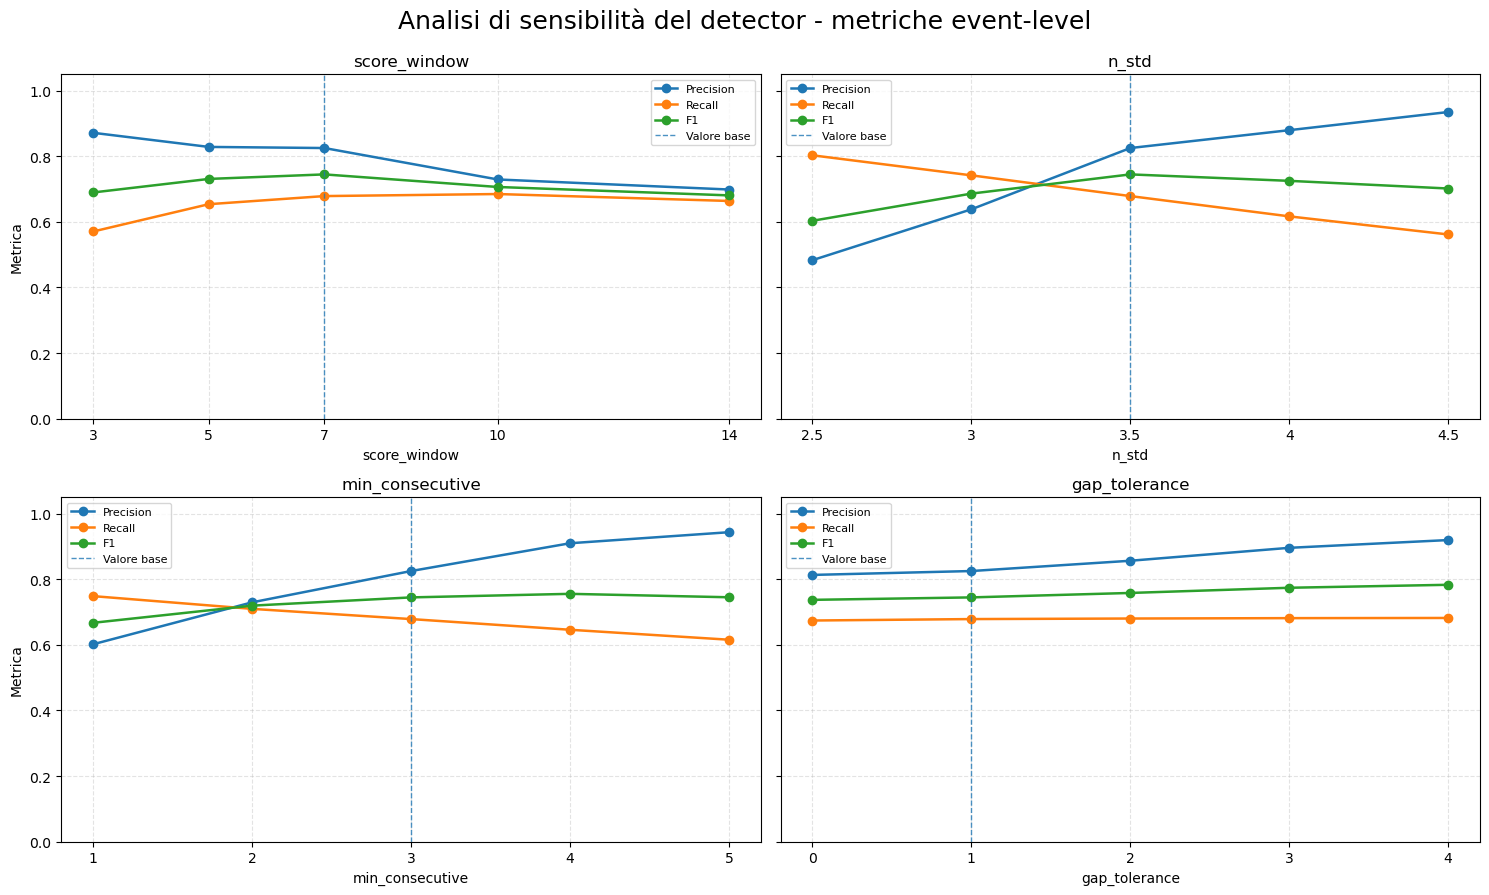

In [14]:
plot_metrics_dashboard(
    agg_main,
    save=True,
)

## Sensibilità rispetto all'intensità dello shift

Questa analisi mostra come la variazione dei parametri interagisce con il moltiplicatore dello shift. I risultati distinguono separatamente aumenti e diminuzioni.

In [15]:
agg_by_multiplier_param_value = aggregate_results(
    raw_results[raw_results["varied_parameter"] != "base_config"],
    group_cols=[
        "varied_parameter",
        "varied_value",
        "multiplier",
    ],
)

agg_by_multiplier_param_value["multiplier"] = pd.to_numeric(
    agg_by_multiplier_param_value["multiplier"],
    errors="coerce",
)

agg_by_multiplier_param_value["varied_value_num"] = pd.to_numeric(
    agg_by_multiplier_param_value["varied_value"],
    errors="coerce",
)

agg_by_multiplier_param_value["multiplier_delta_pct"] = (
    agg_by_multiplier_param_value["multiplier"] - 1.0
) * 100

agg_by_multiplier_param_value = (
    agg_by_multiplier_param_value
    .sort_values([
        "varied_parameter",
        "varied_value_num",
        "multiplier_delta_pct",
    ])
    .reset_index(drop=True)
)

agg_by_multiplier_param_value.to_csv(
    TABLES_DIR / "level_shift_f1_by_multiplier_and_parameter_value.csv",
    index=False,
)

display(
    agg_by_multiplier_param_value[[
        "varied_parameter",
        "varied_value",
        "multiplier",
        "multiplier_delta_pct",
        "n_gt_events",
        "tp",
        "fp",
        "fn",
        "precision_pooled",
        "recall_pooled",
        "f1_pooled",
    ]].round(3)
)

,varied_parameter,varied_value,multiplier,multiplier_delta_pct,n_gt_events,tp,fp,fn,precision_pooled,recall_pooled,f1_pooled
0,gap_tolerance,0,0.700,-30.0,800,800,528,0,0.602,1.000,0.752
1,gap_tolerance,0,0.800,-20.0,800,800,231,0,0.776,1.000,0.874
2,gap_tolerance,0,0.850,-15.0,800,799,145,1,0.846,0.999,0.916
3,gap_tolerance,0,0.900,-10.0,800,612,137,188,0.817,0.765,0.790
4,gap_tolerance,0,0.925,-7.5,800,291,78,509,0.789,0.364,0.498
...,...,...,...,...,...,...,...,...,...,...,...
275,score_window,14,1.075,7.5,800,600,196,200,0.754,0.750,0.752
276,score_window,14,1.100,10.0,800,708,188,92,0.790,0.885,0.835
277,score_window,14,1.150,15.0,800,784,192,16,0.803,0.980,0.883
278,score_window,14,1.200,20.0,800,795,188,5,0.809,0.994,0.892


In [16]:
def plot_f1_multiplier_dashboard(
    anomaly_direction,
    parameters=None,
    save=True,
):
    """
    Dashboard 2x2 della F1 al variare dell'intensità dell'anomalia.

    Ogni pannello corrisponde a un parametro del detector.
    In ciascun pannello:
    - asse x: moltiplicatore;
    - asse y: F1 pooled;
    - linee: valori diversi del parametro considerato.

    anomaly_direction:
    - "increase": usa multiplier > 1
    - "decrease": usa multiplier < 1
    """

    if anomaly_direction not in ["increase", "decrease"]:
        raise ValueError(
            "anomaly_direction deve essere 'increase' oppure 'decrease'."
        )

    if parameters is None:
        parameters = [
            "score_window",
            "n_std",
            "min_consecutive",
            "gap_tolerance",
        ]

    if len(parameters) != 4:
        raise ValueError("Per il cruscotto 2x2 servono esattamente 4 parametri.")

    df_plot = agg_by_multiplier_param_value.copy()

    if anomaly_direction == "increase":
        df_plot = df_plot[df_plot["multiplier"] > 1].copy()
        title_direction = "increase"
    else:
        df_plot = df_plot[df_plot["multiplier"] < 1].copy()
        title_direction = "decrease"

    if df_plot.empty:
        print(f"Nessun dato disponibile per {anomaly_direction}.")
        return

    # Ordine più leggibile per i decrease: da più forte a più debole
    # Esempio: 0.70, 0.80, ..., 0.975
    df_plot = df_plot.sort_values("multiplier")

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(15, 9),
        sharex=True,
        sharey=True,
    )

    axes = axes.flatten()

    for i, (ax, parameter) in enumerate(zip(axes, parameters)):

        g = df_plot[
            df_plot["varied_parameter"] == parameter
        ].copy()

        row_idx = i // 2
        col_idx = i % 2

        if g.empty:
            ax.set_title(parameter)
            ax.text(
                0.5,
                0.5,
                "Nessun dato",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            continue

        g = g.sort_values([
            "varied_value_num",
            "multiplier",
        ])

        for value, gv in g.groupby("varied_value_num", sort=True):
            ax.plot(
                gv["multiplier"],
                gv["f1_pooled"],
                marker="o",
                linewidth=1.8,
                label=f"{value:g}",
            )

        ax.set_title(parameter)
        ax.set_ylim(0, 1.05)

        # Ticker x in formato decimale, non percentuale
        x_ticks = sorted(g["multiplier"].dropna().unique())
        ax.set_xticks(x_ticks)
        ax.xaxis.set_major_formatter(FormatStrFormatter("%.3g"))

        ax.grid(True, linestyle="--", alpha=0.35)

        # Label asse x solo nella riga in basso
        if row_idx == 1:
            ax.set_xlabel("Moltiplicatore")
        else:
            ax.set_xlabel("")
            ax.tick_params(labelbottom=False)

        # Label asse y solo nella colonna sinistra
        if col_idx == 0:
            ax.set_ylabel("F1")
        else:
            ax.set_ylabel("")
            ax.tick_params(labelleft=False)

        ax.legend(
            title=f"Valore {parameter}",
            fontsize=8,
            title_fontsize=8,
            loc="best",
        )

    fig.suptitle(
        f"F1 rispetto all'intensità del level shift - {title_direction}",
        fontsize=18,
        y=0.99,
    )

    plt.tight_layout()

    if save:
        fig_path = (
            FIGURES_DIR
            / f"dashboard_f1_by_multiplier_{anomaly_direction}.png"
        )

        fig.savefig(
            fig_path,
            dpi=300,
            bbox_inches="tight",
        )

        print("Figura salvata:", fig_path)

    plt.show()

    # Evita ristampe multiple in Jupyter
    plt.close(fig)

Figura salvata: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\detector_sensitivity_one_at_a_time\figures\dashboard_f1_by_multiplier_increase.png


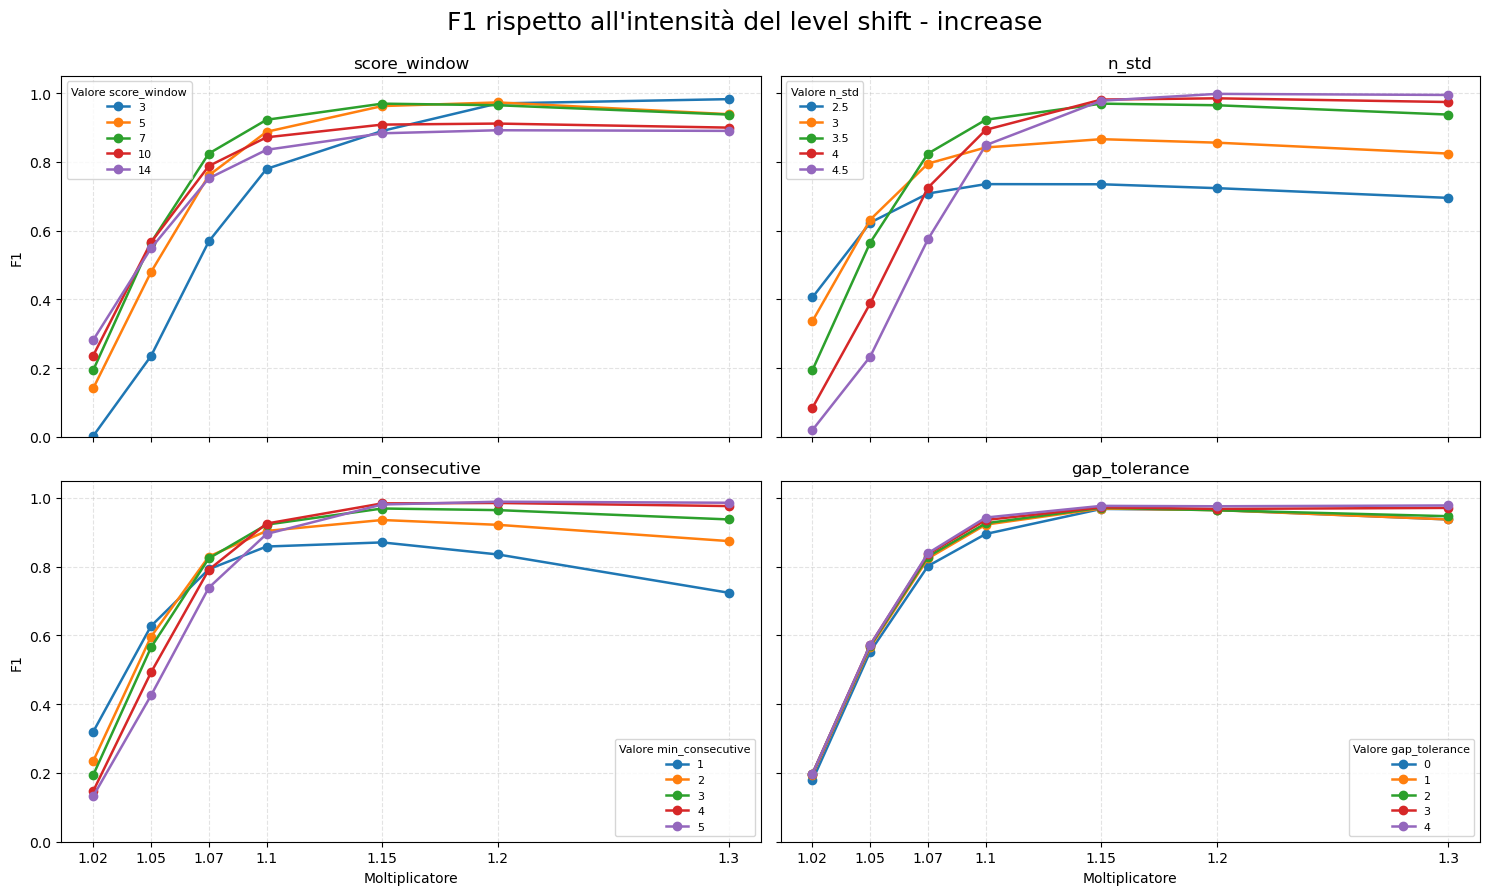

Figura salvata: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\detector_sensitivity_one_at_a_time\figures\dashboard_f1_by_multiplier_decrease.png


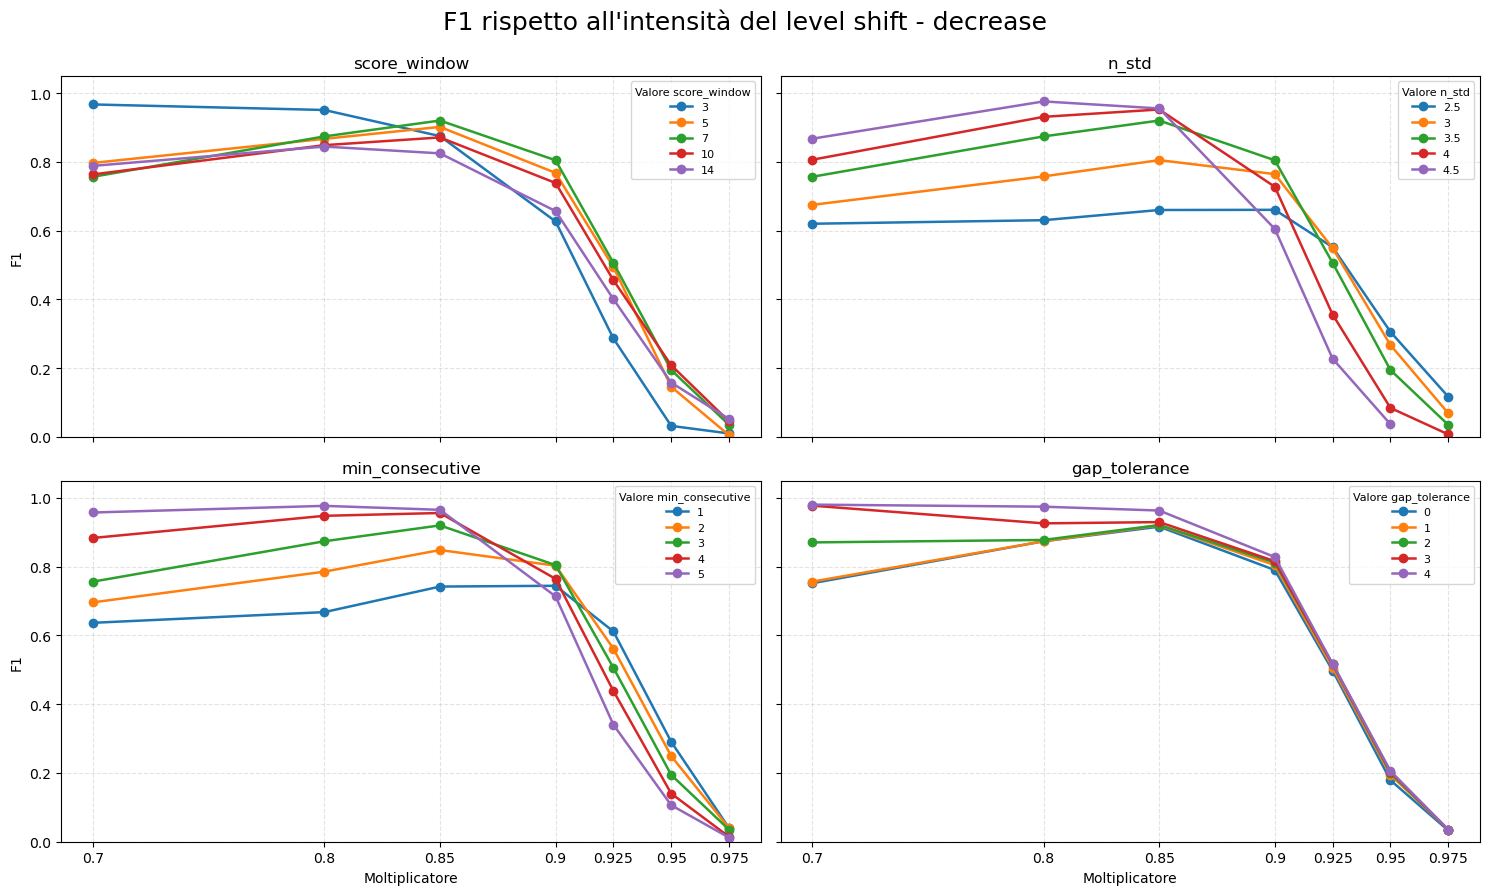

In [17]:
plot_f1_multiplier_dashboard(
    anomaly_direction="increase",
    save=True,
)

plot_f1_multiplier_dashboard(
    anomaly_direction="decrease",
    save=True,
)

## Confronto tra metodi di soglia

Questa analisi è separata dalla griglia one-at-a-time: mantiene fissi i parametri base del detector e confronta soltanto tre modalità di calibrazione store-specific delle soglie:

- `std`: media ± λ·deviazione standard;
- `mad`: mediana ± λ·1.4826·MAD;
- `double_mad`: mediana con scale MAD distinte per la coda inferiore e superiore.

Le soglie sono stimate sul validation set clean. La valutazione usa gli stessi dataset di sensitivity già caricati sopra e le stesse finestre evento della pipeline base.

In [18]:
# I parametri del detector restano fissi alla configurazione base.
THRESHOLD_SCORE_WINDOW = int(BASE_CONFIG["score_window"])
THRESHOLD_MULTIPLIER = float(BASE_CONFIG["n_std"])
THRESHOLD_MIN_CONSECUTIVE = int(BASE_CONFIG["min_consecutive"])
THRESHOLD_GAP_TOLERANCE = int(BASE_CONFIG["gap_tolerance"])
THRESHOLD_IOU_THRESHOLD = float(BASE_CONFIG["iou_threshold"])
THRESHOLD_RESIDUAL_COL = "residual"

## Inference sul validation set clean

Il validation set del dataset clean viene usato una sola volta per costruire gli score e calibrare le soglie dei tre metodi.

In [19]:
if THRESHOLD_VAL_RESULTS_CACHE_PATH.exists() and not FORCE_RECOMPUTE_THRESHOLD_COMPARISON:
    print(
        "Carico validation results clean da cache:",
        THRESHOLD_VAL_RESULTS_CACHE_PATH,
    )

    with open(THRESHOLD_VAL_RESULTS_CACHE_PATH, "rb") as f:
        threshold_val_results = pickle.load(f)

else:
    print("Calcolo inference LSTM sul validation set clean...")

    clean_df = pd.read_csv(CLEAN_DATA_PATH)
    clean_df["date"] = pd.to_datetime(clean_df["date"])
    clean_df = clean_df.sort_values(["store_id", "date"]).reset_index(drop=True)

    _, clean_val, _ = build_dataset_inference(
        clean_df,
        feature_scalers=feature_scalers,
        mappings=mappings,
        features=features,
        window_size=MODEL_WINDOW_SIZE,
        train_size=0.70,
        val_size=0.10,
    )

    clean_val_pred = model.predict(
        build_model_inputs(clean_val),
        verbose=0,
    )

    threshold_val_results = make_results_df(
        clean_val,
        clean_val_pred,
        features,
        feature_scalers,
    )

    # La stessa validation clean viene riusata da tutti i metodi di soglia.
    with open(THRESHOLD_VAL_RESULTS_CACHE_PATH, "wb") as f:
        pickle.dump(threshold_val_results, f)

print(threshold_val_results.shape)

Carico validation results clean da cache: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\detector_sensitivity_one_at_a_time\threshold_method_comparison\_cache\clean_val_results.pkl
(2280, 19)


## Funzioni soglie STD, MAD e Double MAD

Le soglie STD usano media e deviazione standard. Le soglie MAD usano mediana e scala robusta `1.4826 * MAD`. Il Double MAD usa scale separate per le due code della distribuzione degli score.

In [20]:
def thresholds_dict_to_df(thresholds, method_name):
    rows = []

    for store_id, values in thresholds.items():
        row = {"store_id": store_id, "threshold_method": method_name}
        row.update(values)
        rows.append(row)

    return pd.DataFrame(rows).sort_values("store_id").reset_index(drop=True)


def compute_level_shift_mad_thresholds_by_store(
    val_results,
    score_col="level_shift_score",
    store_col="store_id",
    lambda_mad=3.5,
    eps=1e-8,
    fallback_to_std=True,
):
    """
    Calcola soglie robuste store-specific tramite mediana e MAD.

    robust_scale = 1.4826 * median(abs(score - median(score)))

    Se robust_scale è nullo o quasi nullo, usa come fallback la deviazione standard.
    """

    thresholds = {}

    for store_id, g in val_results.groupby(store_col):
        scores = g[score_col].dropna().astype(float)

        if scores.empty:
            raise ValueError(f"Nessuno score valido per store_id={store_id}")

        median = scores.median()
        mad = (scores - median).abs().median()
        robust_scale = 1.4826 * mad

        used_fallback = False

        if robust_scale < eps:
            if fallback_to_std:
                robust_scale = scores.std()
                used_fallback = True

            if pd.isna(robust_scale) or robust_scale < eps:
                robust_scale = eps
                used_fallback = True

        thresholds[store_id] = {
            "lower": median - lambda_mad * robust_scale,
            "upper": median + lambda_mad * robust_scale,
            "center": median,
            "mad": mad,
            "robust_scale": robust_scale,
            "used_fallback": used_fallback,
        }

    return thresholds


def compute_level_shift_double_mad_thresholds_by_store(
    val_results,
    score_col="level_shift_score",
    store_col="store_id",
    threshold_multiplier=3.5,
    mad_factor=1.4826,
    eps=1e-8,
    fallback_to_global_mad=True,
):
    """Calcola soglie asimmetriche con MAD separata per coda."""

    thresholds = {}

    for store_id, g in val_results.groupby(store_col):
        scores = g[score_col].dropna().astype(float)

        if scores.empty:
            raise ValueError(f"Nessuno score valido per store_id={store_id}")

        center = scores.median()
        lower_scores = scores[scores <= center]
        upper_scores = scores[scores >= center]

        lower_mad = (center - lower_scores).median()
        upper_mad = (upper_scores - center).median()
        global_mad = (scores - center).abs().median()

        lower_scale = mad_factor * lower_mad
        upper_scale = mad_factor * upper_mad
        global_scale = mad_factor * global_mad

        used_lower_fallback = False
        used_upper_fallback = False

        if pd.isna(lower_scale) or lower_scale < eps:
            lower_scale = (
                global_scale
                if fallback_to_global_mad
                and pd.notna(global_scale)
                and global_scale >= eps
                else eps
            )
            used_lower_fallback = True

        if pd.isna(upper_scale) or upper_scale < eps:
            upper_scale = (
                global_scale
                if fallback_to_global_mad
                and pd.notna(global_scale)
                and global_scale >= eps
                else eps
            )
            used_upper_fallback = True

        thresholds[store_id] = {
            "lower": center - threshold_multiplier * lower_scale,
            "upper": center + threshold_multiplier * upper_scale,
            "median": center,
            "lower_mad": lower_mad,
            "upper_mad": upper_mad,
            "global_mad": global_mad,
            "lower_scale": lower_scale,
            "upper_scale": upper_scale,
            "global_scale": global_scale,
            "used_lower_fallback": used_lower_fallback,
            "used_upper_fallback": used_upper_fallback,
        }

    return thresholds

## Calcolo e confronto soglie

Le soglie vengono costruite sui medesimi score validation. Il confronto non modifica la griglia one-at-a-time né i parametri base del detector.

In [21]:
# Gli stessi score validation vengono riusati per tutti i metodi di soglia.
threshold_val_scored = add_level_shift_score(
    threshold_val_results,
    residual_col=THRESHOLD_RESIDUAL_COL,
    window=THRESHOLD_SCORE_WINDOW,
)

std_thresholds = compute_level_shift_std_thresholds_by_store(
    threshold_val_scored,
    score_col="level_shift_score",
    store_col="store_id",
    n_std=THRESHOLD_MULTIPLIER,
)

mad_thresholds = compute_level_shift_mad_thresholds_by_store(
    threshold_val_scored,
    score_col="level_shift_score",
    store_col="store_id",
    lambda_mad=THRESHOLD_MULTIPLIER,
)

double_mad_thresholds = compute_level_shift_double_mad_thresholds_by_store(
    threshold_val_scored,
    score_col="level_shift_score",
    store_col="store_id",
    threshold_multiplier=THRESHOLD_MULTIPLIER,
)

THRESHOLD_METHOD_ORDER = ["std", "mad", "double_mad"]
THRESHOLD_METHOD_LABELS = {
    "std": "STD",
    "mad": "MAD",
    "double_mad": "Double MAD",
}

THRESHOLDS_BY_METHOD = {
    "std": std_thresholds,
    "mad": mad_thresholds,
    "double_mad": double_mad_thresholds,
}

thresholds_by_store = pd.concat(
    [
        thresholds_dict_to_df(
            THRESHOLDS_BY_METHOD[method_name],
            method_name,
        )
        for method_name in THRESHOLD_METHOD_ORDER
    ],
    ignore_index=True,
).sort_values(["threshold_method", "store_id"]).reset_index(drop=True)

## Grafico soglie per store

Ogni metodo ha un solo colore: la soglia superiore è continua, mentre la soglia inferiore è tratteggiata. In questo modo il colore identifica sempre la tipologia di calibrazione, non il verso della soglia.

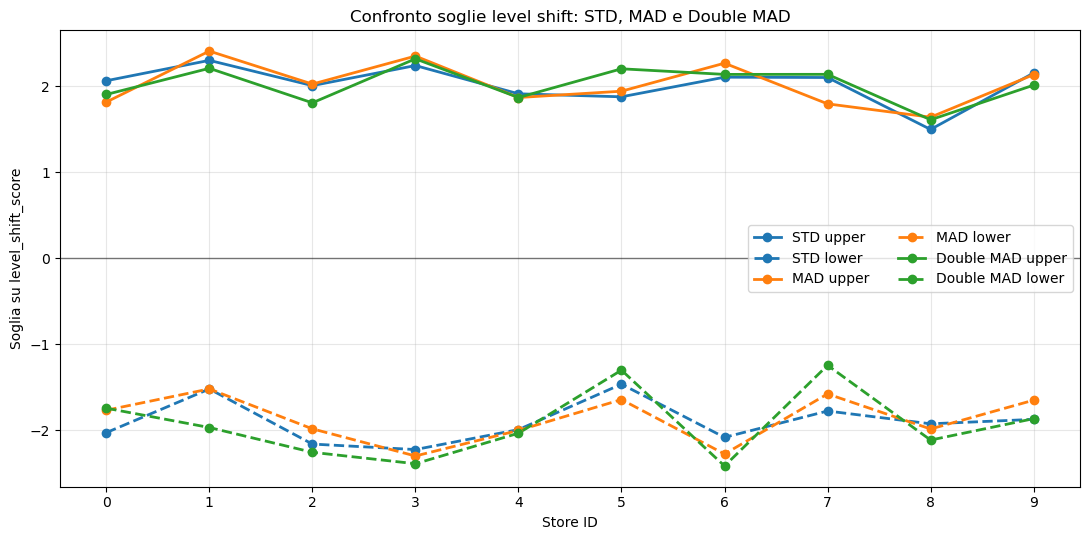

In [22]:
METHOD_PLOT_STYLE = {
    "std": {"color": "tab:blue", "marker": "o"},
    "mad": {"color": "tab:orange", "marker": "o"},
    "double_mad": {"color": "tab:green", "marker": "o"},
}

fig, ax = plt.subplots(figsize=(11, 5.5))

for method_name in THRESHOLD_METHOD_ORDER:
    method_df = (
        thresholds_by_store[
            thresholds_by_store["threshold_method"] == method_name
        ]
        .sort_values("store_id")
        .copy()
    )

    style = METHOD_PLOT_STYLE[method_name]
    label = THRESHOLD_METHOD_LABELS[method_name]

    ax.plot(
        method_df["store_id"],
        method_df["upper"],
        color=style["color"],
        marker=style["marker"],
        linewidth=2,
        linestyle="-",
        label=f"{label} upper",
    )

    ax.plot(
        method_df["store_id"],
        method_df["lower"],
        color=style["color"],
        marker=style["marker"],
        linewidth=2,
        linestyle="--",
        label=f"{label} lower",
    )

ax.axhline(0, linewidth=1, color="black", alpha=0.5)
ax.set_title("Confronto soglie level shift: STD, MAD e Double MAD")
ax.set_xlabel("Store ID")
ax.set_ylabel("Soglia su level_shift_score")
ax.set_xticks(sorted(thresholds_by_store["store_id"].unique()))
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)

plt.tight_layout()

thresholds_figure_path = (
    THRESHOLD_FIGURES_DIR / "thresholds_std_mad_double_mad_by_store.png"
)
fig.savefig(thresholds_figure_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

## Metriche event-level sui dataset di sensitivity

I tre metodi usano la stessa pipeline LSTM, lo stesso score e gli stessi parametri di costruzione e valutazione delle finestre. Cambia soltanto la calibrazione delle soglie.

In [23]:
def get_test_scored_for_threshold_comparison(dataset_row):
    """Recupera i risultati LSTM in cache e calcola lo score con configurazione fissa."""

    dataset_cache = compute_or_load_lstm_results(dataset_row)
    test_results = dataset_cache["test_results"]

    return add_level_shift_score(
        test_results,
        residual_col=THRESHOLD_RESIDUAL_COL,
        window=THRESHOLD_SCORE_WINDOW,
    )


def store_windows(windows, store_id):
    """Filtra una tabella finestre senza fallire quando è vuota."""

    if windows.empty or "store_id" not in windows.columns:
        return windows.copy()

    return windows[windows["store_id"] == store_id].copy()


def evaluate_threshold_method_by_store(test_scored, thresholds, method_name):
    """Restituisce una riga event-level per ogni store del dataset."""

    detected_points = detect_level_shift_from_score_by_store(
        test_scored,
        thresholds,
        score_col="level_shift_score",
        store_col="store_id",
    )

    detected_windows = build_detected_windows_from_center_points(
        detected_points,
        detected_col="is_level_shift_detected_raw",
        window_size=THRESHOLD_SCORE_WINDOW,
        min_consecutive=THRESHOLD_MIN_CONSECUTIVE,
        gap_tolerance=THRESHOLD_GAP_TOLERANCE,
    )

    gt_windows = build_gt_level_shift_windows(test_scored)

    rows = []

    # La valutazione per store evita matching tra eventi di punti vendita diversi.
    for store_id in sorted(test_scored["store_id"].unique()):
        gt_store = store_windows(gt_windows, store_id)
        detected_store = store_windows(detected_windows, store_id)

        _, _, summary = evaluate_detected_windows_event_level(
            gt_windows=gt_store,
            detected_windows=detected_store,
            iou_threshold=THRESHOLD_IOU_THRESHOLD,
        )

        rows.append({
            "store_id": int(store_id),
            "threshold_method": method_name,
            **summary,
        })

    return rows

In [24]:
if THRESHOLD_RAW_METRICS_PATH.exists() and not FORCE_RECOMPUTE_THRESHOLD_COMPARISON:
    threshold_raw_metric_results = pd.read_csv(THRESHOLD_RAW_METRICS_PATH)

    print("Risultati soglie caricati da cache:")
    print(THRESHOLD_RAW_METRICS_PATH)

else:
    threshold_metric_rows = []

    n_datasets = len(datasets_df)
    n_methods = len(THRESHOLD_METHOD_ORDER)

    total_steps = n_datasets * (1 + n_methods)

    with tqdm(
        total=total_steps,
        desc="Threshold comparison",
        unit="step",
    ) as progress_bar:
        for dataset_number, (_, dataset_row) in enumerate(
            datasets_df.iterrows(),
            start=1,
        ):
            progress_bar.set_postfix_str(
                (
                    f"dataset {dataset_number}/{n_datasets} | "
                    f"{dataset_row['direction']} | "
                    f"dur={int(dataset_row['duration'])} | "
                    f"mult={float(dataset_row['multiplier']):.3f} | "
                    f"seed={int(dataset_row['seed'])} | inference"
                )
            )

            test_scored = get_test_scored_for_threshold_comparison(
                dataset_row,
            )

            progress_bar.update(1)

            dataset_id = (
                f"{dataset_row['direction']}|"
                f"{int(dataset_row['duration'])}|"
                f"{float(dataset_row['multiplier']):.6f}|"
                f"{int(dataset_row['seed'])}"
            )

            for method_name in THRESHOLD_METHOD_ORDER:
                progress_bar.set_postfix_str(
                    (
                        f"dataset {dataset_number}/{n_datasets} | "
                        f"{dataset_row['direction']} | "
                        f"dur={int(dataset_row['duration'])} | "
                        f"mult={float(dataset_row['multiplier']):.3f} | "
                        f"seed={int(dataset_row['seed'])} | "
                        f"{method_name}"
                    )
                )

                store_rows = evaluate_threshold_method_by_store(
                    test_scored=test_scored,
                    thresholds=THRESHOLDS_BY_METHOD[method_name],
                    method_name=method_name,
                )

                for row in store_rows:
                    threshold_metric_rows.append({
                        "dataset_id": dataset_id,
                        "direction": dataset_row["direction"],
                        "duration": int(dataset_row["duration"]),
                        "multiplier": float(dataset_row["multiplier"]),
                        "seed": int(dataset_row["seed"]),
                        **row,
                    })

                progress_bar.update(1)

    threshold_raw_metric_results = pd.DataFrame(threshold_metric_rows)
    # Cache finale delle metriche per tutti i dataset e metodi di soglia.
    threshold_raw_metric_results.to_csv(
        THRESHOLD_RAW_METRICS_PATH,
        index=False,
    )

print(f"Righe metriche prodotte: {len(threshold_raw_metric_results):,}")
display(threshold_raw_metric_results.head())

Risultati soglie caricati da cache:
C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\detector_sensitivity_one_at_a_time\threshold_method_comparison\tables\threshold_method_event_metrics_raw_by_store.csv
Righe metriche prodotte: 8,400


,dataset_id,direction,duration,multiplier,seed,store_id,threshold_method,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou,mean_detection_det_offset_start,mean_detection_det_offset_end
0,decrease|7|0.700000|42,decrease,7,0.7,42,0,std,4,8,4,4,0,0.500000,1.0,0.666667,0.459375,-5.50,2.75
1,decrease|7|0.700000|42,decrease,7,0.7,42,1,std,4,6,4,2,0,0.666667,1.0,0.800000,0.459375,-5.25,3.00
2,decrease|7|0.700000|42,decrease,7,0.7,42,2,std,4,6,4,2,0,0.666667,1.0,0.800000,0.438358,-5.75,3.25
3,decrease|7|0.700000|42,decrease,7,0.7,42,3,std,4,6,4,2,0,0.666667,1.0,0.800000,0.453125,-5.75,2.75
4,decrease|7|0.700000|42,decrease,7,0.7,42,4,std,4,8,4,4,0,0.500000,1.0,0.666667,0.452083,-5.50,3.00


## Sintesi pooled finale

Per ciascun metodo vengono prima sommati `TP`, `FP` e `FN`, poi vengono calcolate Precision, Recall e F1.

In [25]:
def threshold_safe_ratio(numerator, denominator):
    return numerator / denominator if denominator > 0 else np.nan


def make_threshold_pooled_summary(df, group_cols):
    rows = []

    for keys, g in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = dict(zip(group_cols, keys))

        tp = int(g["tp"].sum())
        fp = int(g["fp"].sum())
        fn = int(g["fn"].sum())

        # Precision, recall e F1 sono calcolate sui conteggi pooled.
        precision = threshold_safe_ratio(tp, tp + fp)
        recall = threshold_safe_ratio(tp, tp + fn)

        row.update({
            "precision": precision,
            "recall": recall,
            "f1": pooled_f1(precision, recall),
        })
        rows.append(row)

    return pd.DataFrame(rows)


threshold_final_metrics = make_threshold_pooled_summary(
    threshold_raw_metric_results,
    group_cols=["threshold_method"],
)

threshold_final_metrics["threshold_method"] = pd.Categorical(
    threshold_final_metrics["threshold_method"],
    categories=THRESHOLD_METHOD_ORDER,
    ordered=True,
)

threshold_final_metrics = (
    threshold_final_metrics
    .sort_values("threshold_method")
    .reset_index(drop=True)
)

threshold_final_metrics["threshold_method"] = (
    threshold_final_metrics["threshold_method"]
    .map(THRESHOLD_METHOD_LABELS)
)

threshold_final_metrics = threshold_final_metrics.rename(
    columns={
        "threshold_method": "Threshold",
        "precision": "Precision",
        "recall": "Recall",
        "f1": "F1",
    }
)

threshold_final_metrics.to_csv(
    THRESHOLD_FINAL_METRICS_PATH,
    index=False,
)

display(threshold_final_metrics.round(3))

,Threshold,Precision,Recall,F1
0,STD,0.825,0.679,0.745
1,MAD,0.716,0.683,0.699
2,Double MAD,0.817,0.677,0.740
